In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os


datadir  = '/Users/billiemeadowcroft//Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Dome/NEWData/'
plotsdir  = '/Users/billiemeadowcroft//Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Dome/Plots/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [2]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','steelblue','slateblue']
clrs = ['#a6611a','#67a9cf','#02818a']

100600 100600
0
20828
100600 100600
0
20828
3270 3270
414120
0
3270 3270
414120
0


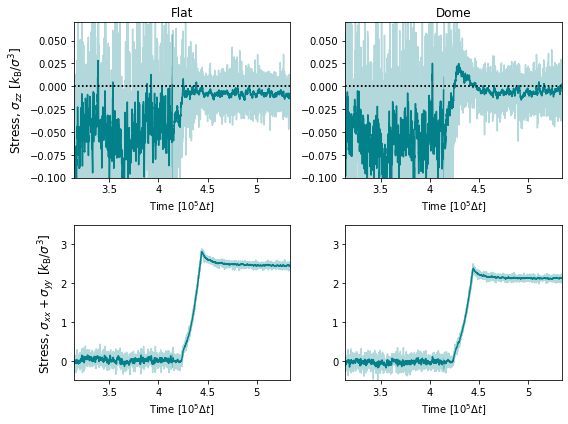

In [3]:
fig,ax = plt.subplots(2,2,figsize = (8,6))
#Timing inputs:
t_mix=0
t_stretch=30000
t_relax=100000
t_bonds=100000

xStretch = "60 30 76".split()
x=0
TimeFrom = 414100
N=30
for ff in range(2):
    for f in range(2):
        #datadir = datadir +namesfolders[f]
        if ff==0 and f==0:
            filename = '/thermo_FlatEqui.dat'
        elif ff==1 and f==0:
            filename = '/thermo_FlatStretch.dat' 
        elif ff==0 and f==1:
            filename = '/thermo_DomeEqui.dat'
        elif ff==1 and f==1:
            filename = '/thermo_DomeStretch.dat'
        #filename = '/thermo.dat'
        thermo = pandas.read_csv(datadir+filename, sep = ' ', header = 'infer')
        etot_, ke_, peBond_,peAngle_, temp_, press_,stressX_,stressY_,stressZ_,AvBondForce_   = thermo.etot,thermo.ke,thermo.peBond,thermo.peAngle,thermo.temp,thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce     
        etot, ke, peBond,peAngle, temp, press,stressX,stressY,stressZ,AvBondForce =etot_.values, ke_.values, peBond_.values,peAngle_.values, temp_.values, press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values
        Time_ = thermo.step
        Time = Time_.values
        if ff==2:
            Time = np.add(Time,129100+TimeFrom)
        print(len(Time),len(stressX))
        Vol = 30*30*12 #165*165*12
        strain = float(xStretch[x])/30 #350/165
        VolTime = []
        tstrcount = 0
        for t in range(len(Time)):
            if Time[t] <= TimeFrom:
                VolTime.append(Vol)
            if Time[t] > TimeFrom and Time[t] <= TimeFrom+t_stretch:
                VolTime.append(Vol+Vol*strain*((Time[tstrcount]-TimeFrom)/t_stretch))
                tstrcount+=1
            if Time[t] > TimeFrom + t_stretch:
                VolTime.append((1+strain)*Vol)
        print(Time[0])
        stressTot = np.add(np.divide(stressY,VolTime),np.divide(stressX,VolTime))
        stressTotAv = np.convolve(stressTot, np.ones(N)/N, mode='valid')
        N=30
        stressZAv = np.convolve(np.divide(stressZ,VolTime), np.ones(N)/N, mode='valid')
        index_endstrain = idx = (np.abs(Time - TimeFrom)).argmin()
        print(index_endstrain)
        if ff==0:
            ax[1,f].plot(Time[:index_endstrain],stressTot[:index_endstrain],color = clrs[2],alpha = 0.3)
            ax[1,f].plot(Time[:index_endstrain],stressTotAv[:index_endstrain],color = clrs[2])
            
            ax[0,f].plot(Time[:index_endstrain],np.divide(stressZ[:index_endstrain],VolTime[:index_endstrain]),color = clrs[2],label = 'Z',alpha = 0.3)
            ax[0,f].plot(Time[:index_endstrain],stressZAv[:index_endstrain],color = clrs[2])
            
            
        elif ff==1:
            ax[1,f].plot(Time,stressTot,color = clrs[2],alpha = 0.3)
            ax[1,f].plot(Time[int(N/2)-1:-int(N/2)],stressTotAv,color = clrs[2])
            ax[0,f].plot(Time[int(N/2)-1:-int(N/2)],stressZAv,color = clrs[2])
            ax[0,f].plot(Time,np.divide(stressZ,VolTime),color = clrs[2],label = 'Z',alpha = 0.3)
        else:
            ax[1,f].plot(Time,stressTot,color = clrs[2],alpha = 0.3)
            ax[1,f].plot(Time[int(N/2)-1:-int(N/2)],stressTotAv,color = clrs[2])
            ax[0,f].plot(Time[int(N/2)-1:-int(N/2)],stressZAv,color = clrs[2])
            
        ax[0,f].plot([TimeFrom-0.1e6,TimeFrom+0.12e6],[0,0],linestyle = ":",color = 'black')
        ax[0,f].set_xlim([TimeFrom-0.1e6,TimeFrom+0.12e6])
        ax[1,f].set_xlim([TimeFrom-0.1e6,TimeFrom+0.12e6])
        ax[0,f].set_ylim([-0.1,0.07])
        ax[1,f].set_ylim([-0.5,3.5])
        ax[0,f].set_xticks([3.5e5,4e5,4.5e5,5e5],['3.5','4','4.5','5'])
        ax[1,f].set_xticks([3.5e5,4e5,4.5e5,5e5],['3.5','4','4.5','5'])
        
        ax[0,f].set_xlabel('Time [$10^{5}\Delta t$]')
        ax[1,f].set_xlabel('Time [$10^{5}\Delta t$]')
ax[0,0].set_title('Flat')
ax[0,1].set_title('Dome')
ax[1,0].set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
#ax[1,0].set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax[0,0].set_ylabel(r'Stress, $\sigma_{zz}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)

fig.tight_layout()
plotname = 'FlatVsDome_zzStress.pdf'
#plotname = 'FlatVsDome_zzStress.png'
#fig.savefig(plotsdir+plotname)



ax[0,0].set_title('Flat')
ax[0,1].set_title('Dome')
ax[1,0].set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax[0,0].set_ylabel(r'Stress, $\sigma_{zz}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
fig.tight_layout()
plotname = 'FlatVsDome_zzStress.pdf'
#plotname = 'FlatVsDome_zzStress.png'
fig.savefig(plotsdir+plotname)